# Statement Forecast: empirical-Bayes dynamic panel

Independent research lab. Not affiliated with any employer or financial institution. Not investment advice.

Liu, L., Moon, H. R., & Schorfheide, F., *Forecasting with Dynamic Panel Data Models*,
NBER Working Paper 25102 (2018); *Econometrica* 88(1), 171–201 (2020).
[Paper](https://www.nber.org/papers/w25102). Integrated likelihood: eq. 24;
parametric Tweedie posterior mean: eqs. 17, 20, 30.

The fixed specification is loaded below from `test_design.json`, including the exact pass bar.
Three quarterly lines, targets 2022Q1–2026Q2, origin-ranked top 50, T=12 rolling equations,
lagged-asset scaling, centered seasonal dummies, Gaussian CRE QMLE and Tweedie correction.
All four methods use the shared Y-9C evaluation cases. No tuning, trimming or outlier removal.

The real-data run requires the specification to match its committed HEAD version. This notebook
is distributed unexecuted; run once on real data and publish the result whatever the verdict.

In [1]:
from pathlib import Path
import sys, os, json, hashlib, subprocess
from datetime import datetime, timezone
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'tracks/y9c-panel/core_items.yaml').exists())
for track in ['tracks/y9c-panel', 'tracks/statement-forecast']:
    sys.path.insert(0, str(ROOT / track))
from y9c.panel import PROCESSED
from statement_forecast.paths import DESIGN_PATH, RESULTS, load_design
from statement_forecast.evaluate import run_all, write_outputs

run_start = datetime.now(timezone.utc).isoformat()
def git(*args):
    return subprocess.check_output(['git', *args], cwd=ROOT)
relative_design = str(DESIGN_PATH.relative_to(ROOT))
try:
    committed = git('show', 'HEAD:' + relative_design)
except subprocess.CalledProcessError as exc:
    raise RuntimeError('Pre-registration must be committed separately before the real-data run') from exc
digest = hashlib.sha256(DESIGN_PATH.read_bytes()).hexdigest()
if digest != hashlib.sha256(committed).hexdigest():
    raise ValueError('test_design.json differs from the committed HEAD pre-registration')
print('Verified test_design.json SHA-256:', digest)
prereg_commit = git('log', '--format=%H', '-n1', '--', relative_design).decode().strip()
if not prereg_commit:
    raise ValueError('Missing pre-registration commit')
run_meta = dict(run_start_time_utc=run_start, git_head=git('rev-parse', 'HEAD').decode().strip(),
                prereg_commit=prereg_commit,
                prereg_commit_time=git('show', '-s', '--format=%cI', prereg_commit).decode().strip(),
                test_design_sha256=digest)
design = load_design()
display(Markdown(design['research_only']))
display(Markdown('**Question:** ' + design['question']))
display(pd.DataFrame(design['lines']))
display(Markdown('**Pass bar:** ' + design['pass_bar']['rule']))
print(json.dumps({key: design[key] for key in ['test_window', 'universe', 'evaluation_cases', 'method']}, indent=2))

panel_path = Path(os.environ['SF_PANEL_PATH']) if 'SF_PANEL_PATH' in os.environ else PROCESSED / 'panel_wide.parquet'
results_dir = Path(os.environ.get('SF_RESULTS_DIR', str(RESULTS)))
# A panel override takes its sibling vintage by default, avoiding the real cache in smoke tests.
vintage_path = Path(os.environ.get('SF_VINTAGE_PATH', str(panel_path.parent / 'vintage.json')))
panel = pd.read_parquet(panel_path)
print('JPMorgan RSSD 1039502; 2024+ quarterly flows, thousands USD')
print(panel.loc[panel.rssd_id.eq(1039502) & panel.report_date.dt.year.ge(2024),
                ['report_date', *[line['column'] for line in design['lines']]]]
      .sort_values('report_date').to_string(index=False))

Verified test_design.json SHA-256: 915d8b220f9dcbdc844d464f7b98db739cc986fa48f9f14e0ed7b73d01ffa68f


Independent research lab. Not affiliated with any employer or financial institution. Not investment advice.

**Question:** Does the Liu-Moon-Schorfheide empirical-Bayes dynamic panel forecaster beat the Y-9C baselines one quarter ahead on three FR Y-9C income-statement lines for the top-50 BHC panel?

,key,column,mdrm,label
0,nii,nii_q,BHCK4074,Net interest income
1,noninterest_income,noninterest_income_q,BHCK4079,Noninterest income
2,noninterest_expense,noninterest_expense_q,BHCK4093,Noninterest expense


**Pass bar:** For a given line, eb_panel PASSES iff MAE(eb_panel) < MAE(naive) AND the full-sample clustered DM two-sided p-value on absolute error (naive vs eb_panel) <= 0.05. An undefined p-value is a FAIL.

{
  "test_window": {
    "first_target": "2022Q1",
    "last_target": "2026Q2",
    "first_origin": "2021Q4",
    "last_origin": "2026Q1",
    "n_target_quarters": 18
  },
  "universe": "Top 50 BHCs by reported BHCK2170 at each origin t, RSSD ID breaks ties; identical to Y-9C (y9c.forecast.design).",
  "evaluation_cases": "Per line, the Y-9C case rule from y9c.forecast: bank selected at origin t, target X_t+1 observed, X_t and X_t-3 observed. All four methods are scored on exactly the same cases within a line.",
  "method": {
    "key": "eb_panel",
    "label": "Empirical-Bayes dynamic panel (LMS Tweedie posterior mean)",
    "citation": "Liu, Laura, Hyungsik Roger Moon, and Frank Schorfheide. Forecasting with Dynamic Panel Data Models. NBER Working Paper 25102 (2018); Econometrica 88(1), 171-201 (2020).",
    "citation_url": "https://www.nber.org/papers/w25102",
    "paper_predictor_followed": "Posterior mean predictor with QMLE common parameters and parametric (Gaussian correlated-ra

## Fixed out-of-sample evaluation

Estimation uses the origin-selected cross-section, independent of whether a next-quarter target exists.
Incomplete ratio windows receive the naive fallback on evaluation cases, with counts reported.
Numerical failures raise. MAE/RMSE are thousands USD, equally weighted by BHC-quarter.
Positive DM t favors EB; two-sided p uses target-quarter CR1 clusters and Student t(G−1).
Per-year results and parameter summaries are **DESCRIPTIVE ONLY**; there is no multiplicity adjustment.

In [2]:
results = run_all(panel, design)
print(results['headline'])
error_format = {'mae': '{:,.0f}', 'rmse': '{:,.0f}'}
for line in design['lines']:
    key = line['key']
    display(Markdown('### ' + line['label']))
    display(results['overall_errors'].query('line == @key').style.format(error_format))
    dm = results['dm_tests'].query('line == @key')
    display(dm.loc[dm.scope.eq('full')].style.format({'t_stat':'{:.3f}', 'p_value':'{:.4f}'}))
    print(json.dumps(results['verdicts'][key], indent=2))
    print('PER-YEAR ERRORS AND DM: DESCRIPTIVE ONLY')
    display(results['by_year_errors'].query('line == @key').style.format(error_format))
    display(dm.loc[dm.scope.ne('full')].style.format({'t_stat':'{:.3f}', 'p_value':'{:.4f}'}))
    print('EB fallbacks:', results['audits'][key]['eb_fallbacks'])
print('EB PARAMETER SUMMARY: DESCRIPTIVE ONLY')
display(results['eb_parameters'].groupby('line')[['rho', 'shrinkage', 'omega2']].agg(['min', 'median', 'max']))
write_outputs(results, results_dir, vintage_path, run_meta)

0 of 3 lines pass


### Net interest income

,method,n_forecasts,mae,rmse,mape,n_mape,mdape,line
0,naive,893,"117,823","275,791",13.081779,893,3.453211,nii
1,seasonal_naive,893,"345,029","767,684",33.801965,893,10.740388,nii
2,pooled_ar,893,"134,049","303,111",14.020305,893,4.266864,nii
3,eb_panel,893,"150,011","341,810",14.475343,893,4.731897,nii


,scope,loss,n,G,df,mean_diff,se,t_stat,p_value,favored,note,inference,line,baseline
0,full,abs,893,18,17,-32187.886798,9140.158901,-3.522,0.0026,naive,CR1; assumes independent target-quarter clusters,"cluster-robust t, df=G-1",nii,naive
1,full,squared,893,18,17,-40772985646.214211,18755733084.972610,-2.174,0.0441,naive,CR1; assumes independent target-quarter clusters,"cluster-robust t, df=G-1",nii,naive
12,full,abs,893,18,17,195017.568969,27326.273608,7.137,0.0000,eb_panel,CR1; assumes independent target-quarter clusters,"cluster-robust t, df=G-1",nii,seasonal_naive
13,full,squared,893,18,17,472504298101.817200,112190887375.949051,4.212,0.0006,eb_panel,CR1; assumes independent target-quarter clusters,"cluster-robust t, df=G-1",nii,seasonal_naive
24,full,abs,893,18,17,-15962.572743,9521.503114,-1.676,0.1119,pooled_ar,CR1; assumes independent target-quarter clusters,"cluster-robust t, df=G-1",nii,pooled_ar
25,full,squared,893,18,17,-24957430212.635429,16882910836.336653,-1.478,0.1576,pooled_ar,CR1; assumes independent target-quarter clusters,"cluster-robust t, df=G-1",nii,pooled_ar


{
  "verdict": "FAIL",
  "passed": false,
  "eb_mae": 150011.1633941675,
  "naive_mae": 117823.27659574468,
  "p_value": 0.0026185453831989577,
  "alpha": 0.05,
  "t_stat": -3.5215894106000776,
  "comparator": "naive",
  "loss": "abs"
}
PER-YEAR ERRORS AND DM: DESCRIPTIVE ONLY


...

{
  "verdict": "FAIL",
  "passed": false,
  "eb_mae": 277329.21283170435,
  "naive_mae": 230601.00223964165,
  "p_value": 0.015825804901738173,
  "alpha": 0.05,
  "t_stat": -2.679867114061905,
  "comparator": "naive",
  "loss": "abs"
}
PER-YEAR ERRORS AND DM: DESCRIPTIVE ONLY


,method,n_forecasts,mae,rmse,mape,n_mape,mdape,target_year,line
40,naive,198,"221,308","450,339",10.376854,198,4.792678,2022,noninterest_expense
41,seasonal_naive,198,"350,794","613,868",17.200706,198,8.613469,2022,noninterest_expense
42,pooled_ar,198,"199,114","418,333",9.865410,198,4.538845,2022,noninterest_expense
43,eb_panel,198,"282,080","536,739",11.697016,198,6.734623,2022,noninterest_expense
44,naive,199,"269,787","703,104",7.846909,199,4.788373,2023,noninterest_expense
45,seasonal_naive,199,"422,458","894,476",14.494686,199,9.823906,2023,noninterest_expense
46,pooled_ar,199,"263,779","673,015",7.702571,199,4.549818,2023,noninterest_expense
47,eb_panel,199,"290,234","676,242",9.445429,199,6.367951,2023,noninterest_expense
48,naive,200,"270,987","711,180",10.011554,200,4.571287,2024,noninterest_expense
49,seasonal_naive,200,"342,805","794,679",12.239010,200,6.155888,2024,noninterest_expense


,scope,loss,n,G,df,mean_diff,se,t_stat,p_value,favored,note,inference,line,baseline
74,2022,abs,198,4,3,-60772.493043,25937.860861,-2.343,0.1009,naive,CR1; assumes independent target-quarter clusters,descriptive only (G=4),noninterest_expense,naive
75,2022,squared,198,4,3,-85283028886.420547,49764531913.678719,-1.714,0.1851,naive,CR1; assumes independent target-quarter clusters,descriptive only (G=4),noninterest_expense,naive
76,2023,abs,199,4,3,-20447.156862,28639.746809,-0.714,0.5268,naive,CR1; assumes independent target-quarter clusters,descriptive only (G=4),noninterest_expense,naive
77,2023,squared,199,4,3,37052666273.639915,62596993143.619606,0.592,0.5955,eb_panel,CR1; assumes independent target-quarter clusters,descriptive only (G=4),noninterest_expense,naive
78,2024,abs,200,4,3,-33858.616350,51435.293107,-0.658,0.5574,naive,CR1; assumes independent target-quarter clusters,descriptive only (G=4),noninterest_expense,naive
79,2024,squared,200,4,3,21894514158.738926,139824304905.786926,0.157,0.8855,eb_panel,CR1; assumes independent target-quarter clusters,descriptive only (G=4),noninterest_expense,naive
80,2025,abs,198,4,3,-90449.802246,46162.831546,-1.959,0.1449,naive,CR1; assumes independent target-quarter clusters,descriptive only (G=4),noninterest_expense,naive
81,2025,squared,198,4,3,-169598410663.201111,106828037726.293167,-1.588,0.2106,naive,CR1; assumes independent target-quarter clusters,descriptive only (G=4),noninterest_expense,naive
82,2026,abs,98,2,1,-9648.674550,38643.706326,-0.250,0.8442,naive,CR1; assumes independent target-quarter clusters,descriptive only (G=2),noninterest_expense,naive
83,2026,squared,98,2,1,21072727796.220081,84273463952.305328,0.250,0.8440,eb_panel,CR1; assumes independent target-quarter clusters,descriptive only (G=2),noninterest_expense,naive


EB fallbacks: 3
EB PARAMETER SUMMARY: DESCRIPTIVE ONLY


rho                     shrinkage                 \
                          min    median       max       min    median  max   
line                                                                         
nii                  0.446088  0.632107  0.817322  0.025842  0.436826  1.0   
noninterest_expense  0.159841  0.465744  0.865728  0.034666  0.190024  1.0   
noninterest_income   0.028339  0.112519  0.826724  0.001465  0.358012  1.0   

                    omega2                       
                       min    median        max  
line                                             
nii                    0.0  0.016105   0.122661  
noninterest_expense    0.0  0.170924   0.461227  
noninterest_income     0.0  0.378621  10.504059

## Aggregate figures

Navy palette; MAE in whole thousands USD. Parameter paths are descriptive only.
No per-bank forecast rows are exported.

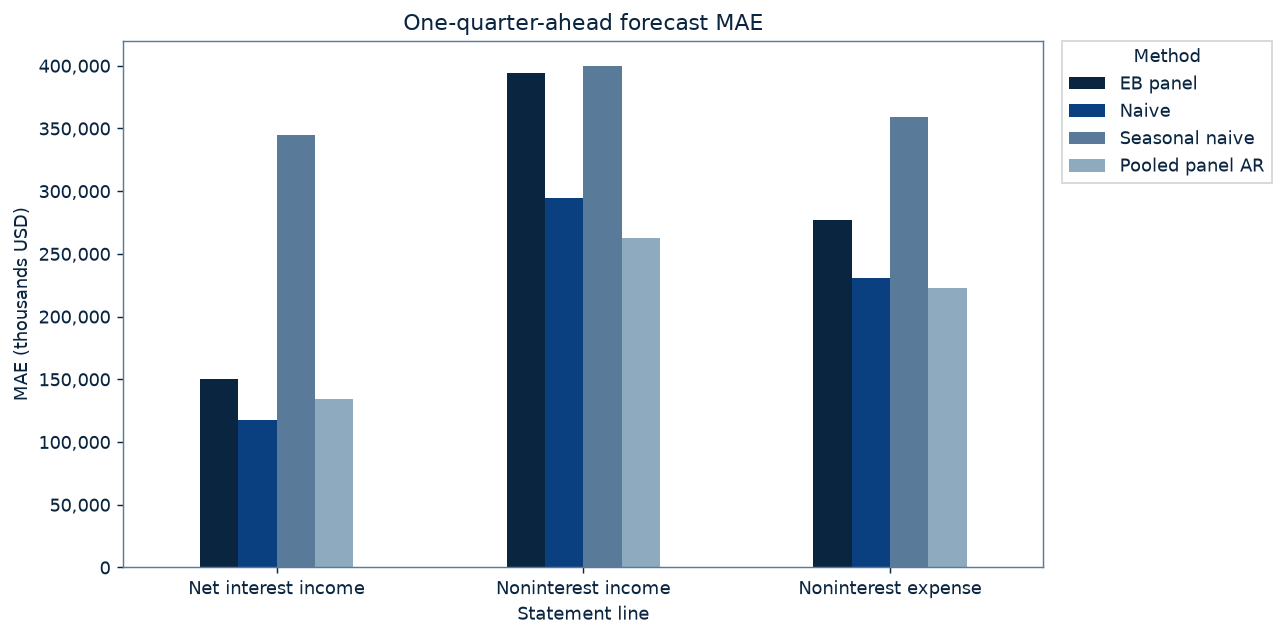

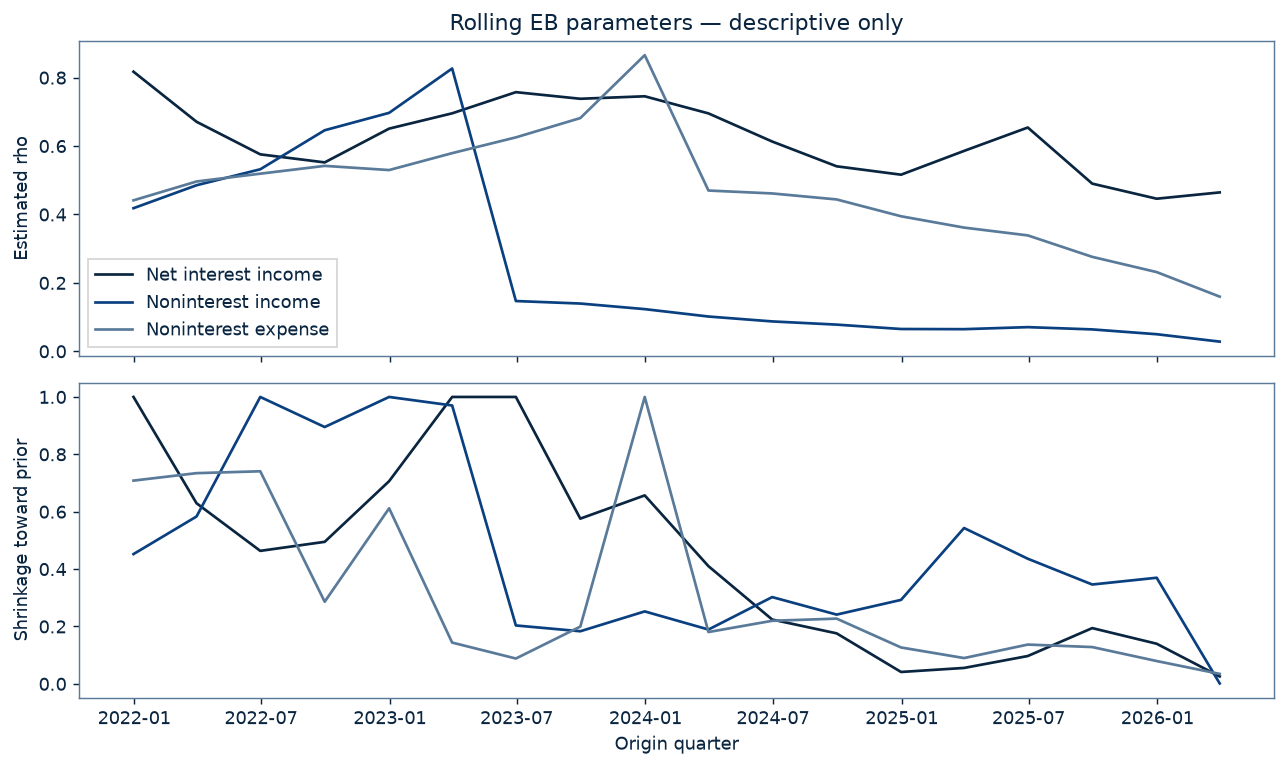

In [3]:
COLORS = ['#0a2540', '#0a4080', '#5a7a9a', '#8daabe']
LABELS = {'eb_panel':'EB panel', 'naive':'Naive', 'seasonal_naive':'Seasonal naive', 'pooled_ar':'Pooled panel AR'}
plt.rcParams.update({'axes.prop_cycle': plt.cycler(color=COLORS), 'figure.dpi':130,
                     'axes.labelcolor':'#0a2540', 'text.color':'#0a2540',
                     'xtick.color':'#0a2540', 'ytick.color':'#0a2540', 'axes.edgecolor':'#5a7a9a',
                     'grid.color':'#8daabe', 'legend.fancybox':False,
                     'figure.facecolor':'white', 'axes.facecolor':'white'})
figures = results_dir / 'figures'
figures.mkdir(parents=True, exist_ok=True)
def save(fig, filename):
    fig.tight_layout()
    fig.savefig(figures / filename, dpi=130, bbox_inches='tight')
    plt.show()
    plt.close(fig)

mae = results['overall_errors'].pivot(index='line', columns='method', values='mae')
mae = mae.reindex(index=[line['key'] for line in design['lines']], columns=list(LABELS))
mae.index = [line['label'] for line in design['lines']]
fig, ax = plt.subplots(figsize=(10, 5))
mae.rename(columns=LABELS).plot.bar(ax=ax, color=COLORS, rot=0)
ax.set(xlabel='Statement line', ylabel='MAE (thousands USD)', title='One-quarter-ahead forecast MAE')
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, pos: f'{value:,.0f}'))
ax.legend(title='Method', loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
save(fig, 'mae_by_line.png')

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for line in design['lines']:
    params = results['eb_parameters'].loc[results['eb_parameters'].line.eq(line['key'])]
    dates = pd.PeriodIndex(params.origin, freq='Q').to_timestamp(how='end').normalize()
    axes[0].plot(dates, params.rho, label=line['label'])
    axes[1].plot(dates, params.shrinkage, label=line['label'])
axes[0].set(ylabel='Estimated rho', title='Rolling EB parameters — descriptive only')
axes[1].set(xlabel='Origin quarter', ylabel='Shrinkage toward prior')
axes[0].legend()
save(fig, 'eb_parameters.png')

## Interpretation and limitations

The headline reports all three pre-registered verdicts, including failures. MAE must strictly improve
on naive and the full-sample absolute-error DM p must be ≤ 0.05; undefined p fails. Other comparisons
and yearly tables are descriptive only. QMLE refits at each origin and posterior means use the
Gaussian CRE score. Seasonal dummies and quarterly observations, the top-50 cross-section, no macro
covariates, and no outlier elimination distinguish this application from the paper.

This is a report-quarter backtest on currently downloaded filings: filing delays and revisions are
not modeled. RSSD histories have no pro-forma merger adjustments, acquisition jumps remain, and
missing calendar predecessors are not bridged. Parent/subsidiary filers are not consolidated.
Dollar losses emphasize large institutions. Research only; not investment advice.